In [1]:
import pandas as pd
from collections import Counter 
from shapely.geometry import Point
import numpy as np
import geopandas as gpd
import plotly.express as px
import plotly.graph_objects as go
from dash import Dash, dcc, html, Input, Output
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from shapely.geometry import Point
# import pysal.lib.weights.set_operations as Wsets
# import pysal.explore.esda.moran as esda
import seaborn as sns
import os
import xarray as xr

In [2]:
df_events = pd.read_csv("../geocodeur/from_hegp/data/data_octobre_2023/medical_event/patients_all_EM.csv", sep = ";")
df_deces = pd.read_csv("../geocodeur/from_hegp/data/data_octobre_2023/date_dc_pseudo.csv", sep = ";")
df_patients = pd.read_csv("Resultats/Excels/patients_FR_IDF_geocoded_adultes_clinique_patho.csv", sep=";")

In [3]:
len(df_events)

5482

In [44]:
def parse_date(date_str):
    for fmt in ('%d/%m/%Y', '%Y-%m-%d %H:%M:%S'):
        try:
            return pd.to_datetime(date_str, format=fmt)
        except ValueError:
            pass
    return pd.to_datetime(date_str, errors='coerce')

In [45]:
#conversion en date
df_events['Date_debut'] = df_events['Date_debut'].apply(parse_date)
df_deces['date_derniere_nouvelle']= df_deces['date_derniere_nouvelle'].apply(parse_date)

#### Evenements médicaux associes au statut des patients

In [46]:
pseudo_EM = df_events['pseudo_provisoire'].unique().tolist()
df_patients_statut = df_events[df_events['pseudo_provisoire'].isin(pseudo_EM)].merge(df_deces, on='pseudo_provisoire')
df_patients_statut = df_patients_statut[(df_patients_statut['Date_debut'].dt.year == 2017) | (df_patients_statut['Date_debut'].dt.year == 2018) | (df_patients_statut['Date_debut'].dt.year == 2019) | (df_patients_statut['Date_debut'].dt.year == 2020) ]
df_patients_statut = df_patients_statut[(df_patients_statut['date_derniere_nouvelle'].dt.year == 2017) | (df_patients_statut['date_derniere_nouvelle'].dt.year == 2018) | (df_patients_statut['date_derniere_nouvelle'].dt.year == 2019) | (df_patients_statut['date_derniere_nouvelle'].dt.year == 2020) ]

#### Nombre de patients distincts

In [47]:
df_patients_statut['annee_EM'] = df_patients_statut['Date_debut'].dt.year
len(df_patients_statut.drop_duplicates(subset=['pseudo_provisoire','annee_EM']))

1886

#### Patients décédés entre 2017-2020

In [48]:
patients_dcd = df_patients_statut[(df_patients_statut['statut_deces']=='oui')]
patients_dcd = patients_dcd.rename(columns={'date_naissance_y': 'date_naissance'})

In [49]:
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
patients_dcd['mois_deces'] = patients_dcd['date_derniere_nouvelle'].dt.strftime('%b')
patients_dcd['année_deces'] = patients_dcd['date_derniere_nouvelle'].dt.year


In [50]:
patients_dcd_2017 = patients_dcd[patients_dcd['année_deces']==2017]
patients_dcd_2018 = patients_dcd[patients_dcd['année_deces']==2018]
patients_dcd_2019 = patients_dcd[patients_dcd['année_deces']==2019]




In [51]:
patients_dcd_2017

,Unnamed: 0.1,Unnamed: 0,pseudo_provisoire,adresse,codepost,nom_commune_postal,requete,x,y,score,...,EM_x,Date_debut,moyenne_all,EM_y,date_naissance,date_derniere_nouvelle,statut_deces,annee_EM,mois_deces,année_deces
75,74,1189,1323,34 RUE SALVADOR ALLENDE,92000.0,NANTERRE,34 RUE SALVADOR ALLENDE 92000 NANT...,2.219655,48.894942,0.975277,...,ira,2017-05-28,19.060000,True,1934-10,2017-06-22,oui,2017,Jun,2017
116,108,1329,1480,14 RUE EUGENE MANUEL,75016.0,PARIS 16E ARRONDISSEMENT,14 RUE EUGENE MANUEL 75016 PARI...,2.281106,48.859457,0.571272,...,unap_appel,2017-07-11,20.043333,True,1960-06,2017-07-16,oui,2017,Jul,2017
130,122,1394,1551,27 RUE PIERRE LHOMME,92400.0,COURBEVOIE,27 RUE PIERRE LHOMME 92400 COUR...,2.251372,48.897619,0.969581,...,ep_mtev,2017-10-16,19.886667,True,1942-11,2017-10-25,oui,2017,Oct,2017
233,223,1718,1912,15 ALLEE DE LA GARENNE,77230.0,DAMMARTIN-EN-GOELE,15 ALLEE DE LA GARENNE 77230 DAMM...,2.688004,49.056609,0.958322,...,ap,2017-07-17,18.210000,True,1960-09,2017-10-08,oui,2017,Oct,2017
234,224,1718,1912,15 ALLEE DE LA GARENNE,77230.0,DAMMARTIN-EN-GOELE,15 ALLEE DE LA GARENNE 77230 DAMM...,2.688004,49.056609,0.958322,...,ap,2017-08-21,18.210000,True,1960-09,2017-10-08,oui,2017,Oct,2017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5569,5387,36749,40415,17 LE CLOS FLEURI,78870.0,BAILLY,17 LE CLOS FLEURI 78870 BAILLY,2.074992,48.841191,0.653875,...,ep_mtev,2017-10-20,16.266667,True,1944-01,2017-10-21,oui,2017,Oct,2017
5621,5436,47463,52454,8 RUE JEAN GABIN,92300.0,LEVALLOIS-PERRET,8 RUE JEAN GABIN 92300 LEVA...,2.277285,48.895355,0.966285,...,ap,2017-02-14,20.556667,True,1974-04,2017-02-16,oui,2017,Feb,2017
5622,5437,47463,52454,8 RUE JEAN GABIN,92300.0,LEVALLOIS-PERRET,8 RUE JEAN GABIN 92300 LEVA...,2.277285,48.895355,0.966285,...,ira,2017-02-14,20.556667,True,1974-04,2017-02-16,oui,2017,Feb,2017
5623,5438,47463,52454,8 RUE JEAN GABIN,92300.0,LEVALLOIS-PERRET,8 RUE JEAN GABIN 92300 LEVA...,2.277285,48.895355,0.966285,...,pneumo,2017-02-14,20.556667,True,1974-04,2017-02-16,oui,2017,Feb,2017


In [52]:
patients_dcd_2017.to_csv('Resultats/Excels/patients_dcd_2017.csv', sep=";")
patients_dcd_2018.to_csv('Resultats/Excels/patients_dcd_2018.csv', sep=";")
patients_dcd_2019.to_csv('Resultats/Excels/patients_dcd_2019.csv', sep=";")

In [53]:
patients_dcd_counts = patients_dcd.drop_duplicates(subset=['pseudo_provisoire','année_deces']).groupby("année_deces").size().reset_index(name='nbre_patients_dcd')
patients_dcd_counts = patients_dcd_counts.rename(columns={'année_deces':'année'})
patients_dcd_counts

,année,nbre_patients_dcd
0,2017,316
1,2018,312
2,2019,423
3,2020,358


In [54]:

patients_dcd['mois_deces'] = pd.Categorical(patients_dcd['mois_deces'], categories=month_order, ordered=True)

dcd_em_counts = patients_dcd.groupby(['année_deces', 'mois_deces']).size().reset_index(name='count')
df_monthly_totals = patients_dcd.groupby(['année_deces','mois_deces']).size().reset_index(name='total_count')

C:\Users\lpokambo\AppData\Local\Temp\ipykernel_16032\2537697414.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\lpokambo\AppData\Local\Temp\ipykernel_16032\2537697414.py:4: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [55]:
fig = px.line(dcd_em_counts, 
              x='mois_deces', 
              y='count',
              color='année_deces',
              labels={'count': 'Nombre de décès', 'mois':'mois', 'année':'année'},
              title='Nombre de décès en fonction de l\'année')
fig.show()

#### Nombre de patients ayant fait des EM par année

In [56]:
df_patients_statut['année'] = df_patients_statut['Date_debut'].dt.year
patients_em_counts = df_patients_statut.drop_duplicates(subset=['pseudo_provisoire', 'année']).groupby("année").size().reset_index(name='nbre_patients')
patients_em_counts

,année,nbre_patients
0,2017,650
1,2018,489
2,2019,603
3,2020,144


#### Nombre d'évènements médicaux par année

In [57]:
#Nombre d'événements par année
events_per_year = df_patients_statut.groupby('année').size().reset_index(name='nombre_evenements')
events_per_year

,année,nombre_evenements
0,2017,1166
1,2018,897
2,2019,1114
3,2020,222


In [58]:
# Création du DataFrame df_stats_annee avec les années
df_stats_annee = pd.DataFrame({"année": [2017, 2018, 2019, 2020]})

# Fusionner les résultats dans df_stats_annee
df_stats_annee = pd.merge(df_stats_annee, patients_em_counts, on='année', how='left')
df_stats_annee = pd.merge(df_stats_annee, events_per_year, on='année', how='left')
df_stats_annee = pd.merge(df_stats_annee, patients_dcd_counts, on='année', how='left')

# Remplir les valeurs manquantes avec 0 si nécessaire
df_stats_annee['nbre_patients'].fillna(0, inplace=True)
df_stats_annee['nbre_patients_dcd'].fillna(0, inplace=True)
df_stats_annee['nombre_evenements'].fillna(0, inplace=True)

# Convertir les colonnes en entiers
df_stats_annee['nbre_patients'] = df_stats_annee['nbre_patients'].astype(int)
df_stats_annee['nbre_patients_dcd'] = df_stats_annee['nbre_patients_dcd'].astype(int)
df_stats_annee['nombre_evenements'] = df_stats_annee['nombre_evenements'].astype(int)


# # Calcul du nombre de patients en vie à la fin de chaque année
# df_stats_annee['patients_vivants_fin_annee'] = df_stats_annee['patients_em'].cumsum() - df_stats_annee['patients_dcd'].cumsum()

# # Calcul du ratio événements médicaux par patient
# df_stats_annee['ratio_evenements_par_patient'] = df_stats_annee['nombre_evenements'] / df_stats_annee['patients_em']

# # Calcul du taux de mortalité des patients EM
# df_stats_annee['taux_mortalite'] = df_stats_annee['patients_dcd'] / df_stats_annee['patients_em']


# Afficher le DataFrame final
df_stats_annee

C:\Users\lpokambo\AppData\Local\Temp\ipykernel_16032\2574044987.py:10: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



C:\Users\lpokambo\AppData\Local\Temp\ipykernel_16032\2574044987.py:11: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, 

,année,nbre_patients,nombre_evenements,nbre_patients_dcd
0,2017,650,1166,316
1,2018,489,897,312
2,2019,603,1114,423
3,2020,144,222,358


In [59]:
# Listes pour stocker les résultats
annee = [2017,2018,2019,2020]
nombre_evenements_medicaux = []
patients_decedes = []
patients_total = []
patients_annee = []

# DataFrame initial avec tous les patients vivants en 2016
cumul_patients_EM_i_1 = df_events[df_events['Date_debut'].dt.year == 2016].drop_duplicates(subset='pseudo_provisoire')


# Boucle sur chaque année
for i, an in enumerate(annee):
    # Patients ayant fait des événements médicaux pour l'année en cours
    patients_an = df_patients_statut[df_patients_statut['Date_debut'].dt.year == an].drop_duplicates(subset='pseudo_provisoire')
    patients_annee.append(len(patients_an))

    # Nombre total de patients au début de l'année
    total_patients_beginning_year = pd.concat([patients_an, cumul_patients_EM_i_1]).drop_duplicates(subset='pseudo_provisoire')
    patients_total.append(len(total_patients_beginning_year))
    
    # Debugging print statements

    print(f"Année {an}:")
    print(f"Patients ayant fait des EM l'année en cours: {len(patients_an)}")
    print(f"Patients ayant fait des EM de l'année précédente: {len((df_patients_statut[df_patients_statut['Date_debut'].dt.year == annee[i-1]]).drop_duplicates(subset = 'pseudo_provisoire'))}")
    print(f"Cumul patients vivants ayant fait des EM: {len(cumul_patients_EM_i_1)}")
    print(f"Cumul patients ayant fait des EM: {len(total_patients_beginning_year)}")
    

    # Nombre d'événements médicaux pour l'année en cours
    nombre_evenements = df_patients_statut[df_patients_statut['Date_debut'].dt.year == an]
    nombre_evenements_medicaux.append(len(nombre_evenements))
    
    # Filtrer les patients décédés pour l'année en cours
    decedes_an = total_patients_beginning_year[(total_patients_beginning_year['date_derniere_nouvelle'].dt.year == an )&(total_patients_beginning_year['statut_deces']=='oui')]
    
    # Nombre de patients décédés pour l'année en cours
    patients_decedes.append(len(decedes_an))
    
    # Mettre à jour la liste des patients vivants pour l'année suivante
    patients_morts = cumul_patients_EM_i_1[cumul_patients_EM_i_1['pseudo_provisoire'].isin(decedes_an['pseudo_provisoire'])]
    patients_vivants = cumul_patients_EM_i_1[~cumul_patients_EM_i_1['pseudo_provisoire'].isin(decedes_an['pseudo_provisoire'])]

    print(f"Patients morts ayant fait des EM de l'année précédente: {len(patients_morts)}")
    print(f"Patients vivant ayant fait des EM de l'année précédente: {len(patients_vivants)}")
    
    print(f"Patients vivants ayant fait des EM en {an}: {len(patients_an[patients_an['statut_deces'] == 'non'])}")
  
    
    # Ajouter les patients de l'année en cours qui sont encore en vie
    cumul_patients_EM_i_1 = total_patients_beginning_year
    
# Création d'un DataFrame pour les résultats
df_stats_annee = pd.DataFrame({
    'année': annee,
    'cumul_patients_ayant_fait_EM': patients_total,
    'nombre de patients': patients_annee,
    'nombre_evenements_medicaux': nombre_evenements_medicaux,
    'patients_decedes': patients_decedes
})

# Affichage des résultats
df_stats_annee


Année 2017:
Patients ayant fait des EM l'année en cours: 650
Patients ayant fait des EM de l'année précédente: 144
Cumul patients vivants ayant fait des EM: 17
Cumul patients ayant fait des EM: 666
Patients morts ayant fait des EM de l'année précédente: 1
Patients vivant ayant fait des EM de l'année précédente: 16
Patients vivants ayant fait des EM en 2017: 87
Année 2018:
Patients ayant fait des EM l'année en cours: 489
Patients ayant fait des EM de l'année précédente: 650
Cumul patients vivants ayant fait des EM: 666
Cumul patients ayant fait des EM: 1059
Patients morts ayant fait des EM de l'année précédente: 145
Patients vivant ayant fait des EM de l'année précédente: 521
Patients vivants ayant fait des EM en 2018: 56
Année 2019:
Patients ayant fait des EM l'année en cours: 603
Patients ayant fait des EM de l'année précédente: 489
Cumul patients vivants ayant fait des EM: 1059
Cumul patients ayant fait des EM: 1510
Patients morts ayant fait des EM de l'année précédente: 190
Patients

,année,cumul_patients_ayant_fait_EM,nombre de patients,nombre_evenements_medicaux,patients_decedes
0,2017,666,650,1166,316
1,2018,1059,489,897,311
2,2019,1510,603,1114,423
3,2020,1613,144,222,358


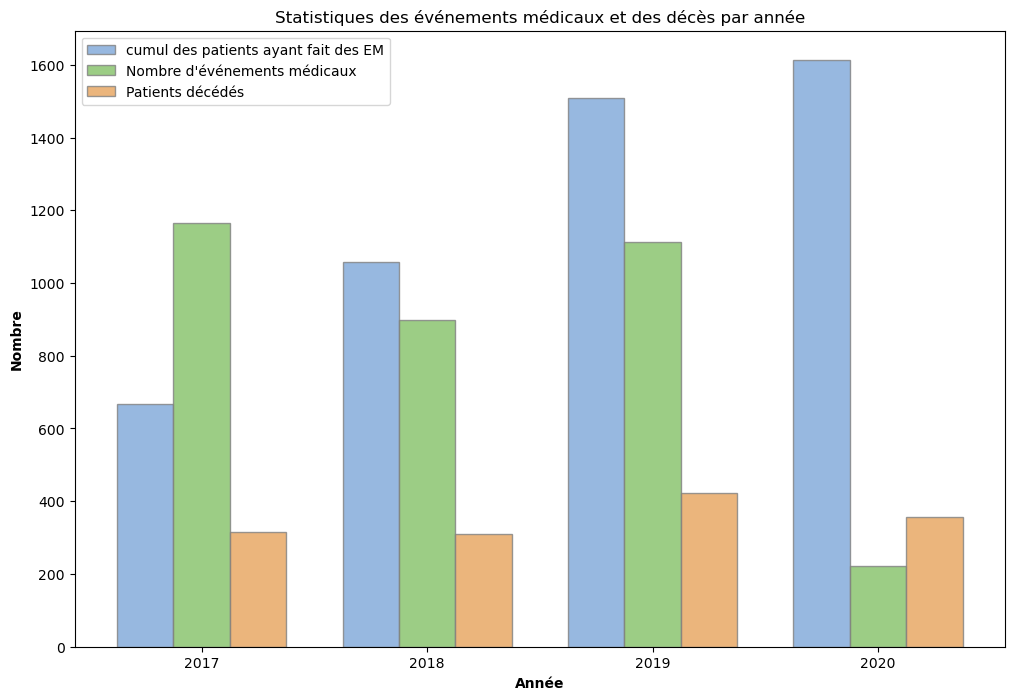

In [60]:
# Visualisation des résultats
plt.figure(figsize=(12, 8))

# Barres pour les patients initiaux
bar_width = 0.25
r1 = range(len(annee))
r2 = [x + bar_width for x in r1]
r3 = [x + bar_width for x in r2]

# Couleurs plus douces
colors = {
    'cumul_patients_ayant_fait_EM': '#7da7d9',  # Blue with transparency
    'nombre_evenements_medicaux': '#83c167',  # Green with transparency
    'patients_decedes': '#e7a35b'  # Orange with transparency
}

plt.bar(r1, df_stats_annee['cumul_patients_ayant_fait_EM'], color=colors['cumul_patients_ayant_fait_EM'], width=bar_width, edgecolor='grey', label='cumul des patients ayant fait des EM', alpha=0.8)
plt.bar(r2, df_stats_annee['nombre_evenements_medicaux'], color=colors['nombre_evenements_medicaux'], width=bar_width, edgecolor='grey', label='Nombre d\'événements médicaux', alpha=0.8)
plt.bar(r3, df_stats_annee['patients_decedes'], color=colors['patients_decedes'], width=bar_width, edgecolor='grey', label='Patients décédés', alpha=0.8)

# Ajouter des labels et un titre
plt.xlabel('Année', fontweight='bold')
plt.ylabel('Nombre', fontweight='bold')
plt.title('Statistiques des événements médicaux et des décès par année')
plt.xticks([r + bar_width for r in range(len(annee))], annee)
plt.legend()

# Afficher le graphique
plt.show()

In [61]:
# Configuration du graphique
plt.figure(figsize=(14, 8))
bar_width = 0.2
index = np.arange(len(df_stats_annee['année']))

# Barres pour les patients ayant fait des événements médicaux
bar1 = plt.bar(index, df_stats_annee['cumul_patients_vivants_ayant_fait_EM'], bar_width, label='cumul des patients vivants ayant fait des EM', color='b')

# Barres pour les patients décédés
bar2 = plt.bar(index + bar_width, df_stats_annee['patients_decedes'], bar_width, label='Patients DCD', color='r')

# Barres pour les événements médicaux
bar3 = plt.bar(index + 2 * bar_width, df_stats_annee['nombre_evenements_medicaux'], bar_width, label='Nombre d\'événements médicaux', color='g')

# Ajouter des annotations au-dessus des barres
for bars in [bar1, bar2, bar3]:
    for bar in bars:
        height = bar.get_height()
        plt.annotate('{}'.format(int(height)),
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3),  # 3 points au-dessus de la barre
                     textcoords="offset points",
                     ha='center', va='bottom')

# Ajouter des labels et un titre
plt.xlabel('Année')
plt.ylabel('Nombre')
plt.title('Statistiques médicales par année')
plt.xticks(index + bar_width, df_stats_annee['année'])
plt.legend()

# Afficher le graphique
plt.tight_layout()
plt.show()

KeyError: 'cumul_patients_vivants_ayant_fait_EM'

<Figure size 1400x800 with 0 Axes>

In [ ]:
# Calcul des cumuls
df_stats_annee['cumul_patients_decedes'] = df_stats_annee['patients_decedes'].cumsum()

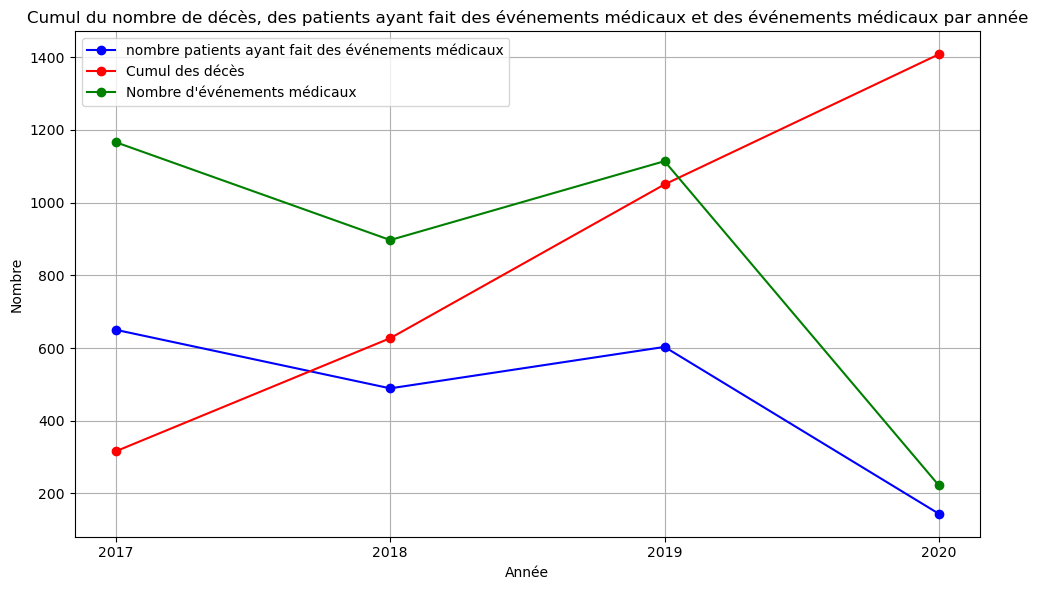

In [ ]:
df_plot = df_stats_annee[['année', 'cumul_patients_decedes', 'nombre de patients', 'nombre_evenements_medicaux']]
# Tracé de la courbe pour le nombre d'événements médicaux
plt.figure(figsize=(10, 6))

# Tracé du cumul des patients ayant fait des événements médicaux
plt.plot(df_plot['année'], df_plot['nombre de patients'], marker='o', linestyle='-', color='b', label= 'nombre patients ayant fait des événements médicaux')

# Tracé du cumul du nombre de décès
plt.plot(df_plot['année'], df_plot['cumul_patients_decedes'], marker='o', linestyle='-', color='r', label='Cumul des décès')

# Tracé du nombre d'événements médicaux par année
plt.plot(df_plot['année'], df_plot['nombre_evenements_medicaux'], marker='o', linestyle='-', color='g', label='Nombre d\'événements médicaux')

# Ajout de titres et de légendes
plt.title('Cumul du nombre de décès, des patients ayant fait des événements médicaux et des événements médicaux par année')
plt.xlabel('Année')
plt.ylabel('Nombre')
plt.xticks(df_plot['année'])
plt.legend()

# Affichage du graphique
plt.grid(True)
plt.tight_layout()
plt.show()

# EVENEMENTS MEDICAUX EN FONCTION DE LA SAISONNALITE

In [ ]:
df_event_counts = df_events.groupby(['Date_debut']).size().reset_index(name='count')
fig = px.bar(df_event_counts, 
              x='Date_debut', 
              y='count', 
              title='Nombre d\'événements cliniques par type et par période',
              labels={
                  'Date_debut':'Date de l\'evenement',
                  'count':'nombre d\'evenements',
              })

fig.update_xaxes(rangeslider_visible=True)
fig.show()

In [ ]:
df_event_counts = df_events.groupby(['Date_debut', 'EM_x']).size().reset_index(name='count')
fig = px.line(df_event_counts, 
              x='Date_debut', 
              y='count', 
              color='EM_x',
              title='Nombre d\'événements cliniques par type et par période',
              labels={
                  'Date_debut':'Date de l\'evenement',
                  'count':'nombre d\'evenements',
                  'EM_x':'type d\'evenement'
              })

fig.update_xaxes(rangeslider_visible=True)
fig.show()

In [ ]:
df_events['mois'] = df_events['Date_debut'].dt.strftime('%b')
df_events['année'] = df_events['Date_debut'].dt.year

month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df_events['mois'] = pd.Categorical(df_events['mois'], categories=month_order, ordered=True)

df_event_counts = df_events.groupby(['année', 'mois']).size().reset_index(name='count')
df_monthly_totals = df_events.groupby(['année','mois']).size().reset_index(name='total_count')



fig = px.line(df_event_counts, 
              x='mois', 
              y='count',
              color='année',
              labels={'count': 'Nombre d\'événements', 'mois':'mois', 'année':'année'},
              title='Nombre d\'événements cliniques par mois en fonction de l\'année')


# for year in df_event_counts['année'].unique():
#     df_yearly_totals = df_event_counts[df_event_counts['année'] == year]
#     fig.add_trace(go.Scatter(
#         x=df_yearly_totals['mois'],
#         y=df_yearly_totals['count'],
#         mode='markers+text',
#         text=df_yearly_totals['count'],
#         textposition='top center',
#         name=f'Total {year}',
#         showlegend=False,
#         marker=dict(size=4)  # Vous pouvez ajuster la couleur et la taille
#     ))


fig.update_layout(xaxis_title = 'mois', yaxis_title='nombre d\'évènements', legend_title = 'Année')
# config = {
#         'toImageButtonOptions': {
#             'format': 'png',  # one of png, svg, jpeg, webp
#             'filename': 'chomage',
#             'height': 1080,
#             'width': 1920,
#             'scale': 6  # Multiply title/legend/axis/canvas sizes by this factor
#         }
#     }

# Show the figure
fig.show()# config=config)





C:\Users\lpokambo\AppData\Local\Temp\ipykernel_21980\3053717003.py:7: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\lpokambo\AppData\Local\Temp\ipykernel_21980\3053717003.py:8: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [ ]:
def get_season(date):
    month = date.month
    if month == 12:
        return 'Hiver (Dec - Fev)'
    if month in [12, 1, 2]:
        return 'Hiver (Dec - Fev)'
    elif month in [3, 4, 5]:
        return 'Printemps (Mars - Mai)'
    elif month in [6, 7, 8]:
        return 'Ete (Juin - Aout)'
    elif month in [9, 10, 11]:
        return 'Automne (Sept - Nov)'
  

In [ ]:
df_events = df_events[~((df_events['Date_debut'].dt.year == 2020) & (df_events['Date_debut'].dt.month == 12))]

df_events['saison'] = df_events['Date_debut'].apply(get_season)

df_events['année'] = df_events['Date_debut'].dt.year

df_events.to_csv("../geocodeur/from_hegp/data/data_octobre_2023/medical_event/patients_all_EM_saison.csv", sep = ";")




df_events['année'] = df_events['Date_debut'].apply(lambda x: x.year + 1 if x.month == 12 else x.year)

print(sum(df_events['année']==2018))
df_event_counts = df_events.groupby(['année', 'saison']).size().reset_index(name='count')



season_order = ['Hiver (Dec - Fev)', 'Printemps (Mars - Mai)', 'Ete (Juin - Aout)', 'Automne (Sept - Nov)']
df_event_counts['saison'] = pd.Categorical(df_event_counts['saison'], categories=season_order, ordered=True)

df_event_counts = df_event_counts.sort_values('saison').reset_index(drop=True)

df_event_counts


fig = px.line(df_event_counts, 
              x='saison', 
              y='count',
              color='année',
              labels={'count': 'Nombre d\'événements', 'saison':'Saison', 'année':'Année'},
              title='Nombre d\'événements médicaux par saison en fonction de l\'année')

fig.update_layout(xaxis_title='Saison', yaxis_title='Nombre d\'événements', legend_title='Année')
config = {
        'toImageButtonOptions': {
            'format': 'png',  # one of png, svg, jpeg, webp
            'filename': 'chomage',
            'height': 1080,
            'width': 1920,
            'scale': 10 # Multiply title/legend/axis/canvas sizes by this factor
        }
    }

#Show the figure
fig.show(config = config)

1516
